In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import seaborn as sns
import os
from graph_tool.all import *
import scipy as sp
import sklearn
from tqdm import tqdm
from scipy.interpolate import make_smoothing_spline
from sklearn.metrics import r2_score

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

import imageio
import os
import shutil
import sys

PROJECT_ROOT = "../"
sys.path.insert(0, str(PROJECT_ROOT))

from src.analysis.loaders import load_all_ploidy_liquid, load_all_ploidy, load_stability_results_solid, load_stability_results_liquid, load_ensemble

In [2]:
### Error areas x ###
def return_stats(vec, interv):
    means =[]
    stds = []
    for i in range(len(interv)-1):
        provv = []
        for j in range(len(vec)):
            provv.append(np.where(np.logical_and(vec[j]>interv[i],vec[j]<=interv[i+1]))[0])
        provv = np.concatenate(provv)
        means.append(np.mean(provv))
        stds.append(np.std(provv))
    
    return np.array(means), np.array(stds)

def reconstruct_ymean(mm, space):
    x = []
    for i in range(int(max(mm))):
        p0 = np.where(mm<=i)[0][-1]
        p1 = np.where(mm>i)[0][0]
        slope = space/(mm[p1]-mm[p0])
        x.append(interv_0[p0]+slope*1)
    return np.array(x)

def running_slope(x, skip):
    vec = []
    for i in range(skip, len(x)-skip-1):
        vec.append((x[i+skip]-x[i])/skip)
    return np.array(vec)

### Error areas y ###
def stats_elementwise(vs):
    """
    Compute element-wise mean and standard deviation across uneven-length sequences,
    ignoring out-of-range indices and NaNs.

    Parameters
    ----------
    vs : list of array-like
        A list of sequences (lists or numpy arrays) of possibly different lengths.

    Returns
    -------
    means : numpy.ndarray
        Array of length max(len(v) for v in vs) containing the mean at each position.
    stds : numpy.ndarray
        Array of same length containing the standard deviation at each position.
    """
    # Determine the maximum length
    n = max(len(v) for v in vs)
    
    # Preallocate results
    means = np.empty(n, dtype=float)
    stds = []
    
    for i in range(n):
        # Collect valid values at position i
        vals = [v[i] for v in vs if i < len(v) and not np.isnan(v[i])]
        
        if vals:
            arr = np.array(vals, dtype=float)
            means[i] = np.quantile(arr, 0.5)
            stds.append([np.quantile(arr, 0.159), np.quantile(arr, 0.841)]) # population std; use ddof=1 for sample std
        else:
            means[i] = np.nan
            stds.append([np.nan, np.nan])
            
    return np.array(means), np.array(stds)

def plot_stats_elementwise(x, ax, label="", color="C0", lw=3, alpha=0.3):
    means, stds = stats_elementwise(x)
    
    ax.plot(np.arange(len(means)), means, color=color, lw=lw, label=label)
    ax.fill_between(np.arange(len(means)) ,stds[:,0], stds[:,1], color=color, alpha=alpha)

In [9]:
ens = load_ensemble("ensemble_results_D")

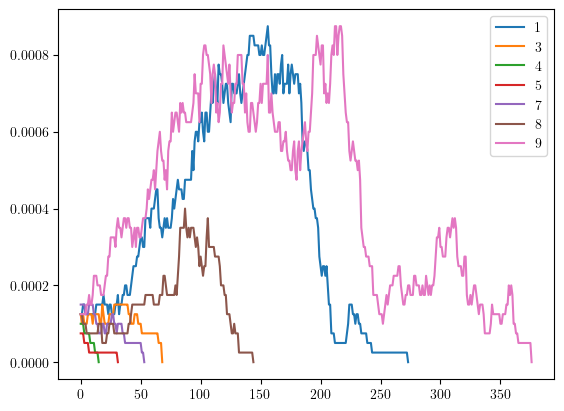

In [17]:
for i in range(10):
    if ens[1][i]['outcome_code']==0:
        plt.plot(ens[1][i]['tumor_density'], label=str(i+1))
plt.legend()

In [28]:
data_l = load_all_ploidy_liquid()
data_s = load_all_ploidy()

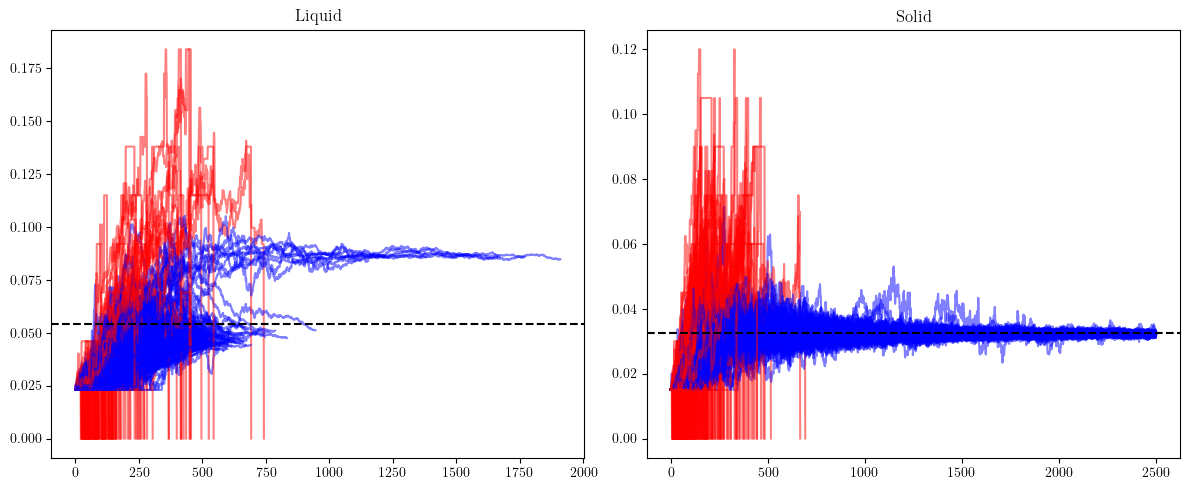

In [29]:
_, ax = plt.subplots(1,2,figsize=(12,5))

for i in range(500):
    if data_l['Diploid'][1][i]['outcome_code']==0:
        ax[0].plot(data_l['Diploid'][1][i]['mu'], color="r", alpha=0.5)
    else:
        ax[0].plot(data_l['Diploid'][1][i]['mu'], color="b", alpha=0.5)

ax[0].axhline(0.054, color="k", ls="--")
ax[0].set_title("Liquid")

for i in range(500):
    if data_s['Diploid'][1][i]['outcome_code']==0:
        ax[1].plot(data_s['Diploid'][1][i]['mu'], color="r", alpha=0.5)
    else:
        ax[1].plot(data_s['Diploid'][1][i]['mu'], color="b", alpha=0.5)

ax[1].axhline(0.032614, color="k", ls="--")
ax[1].set_title("Solid")

plt.tight_layout()

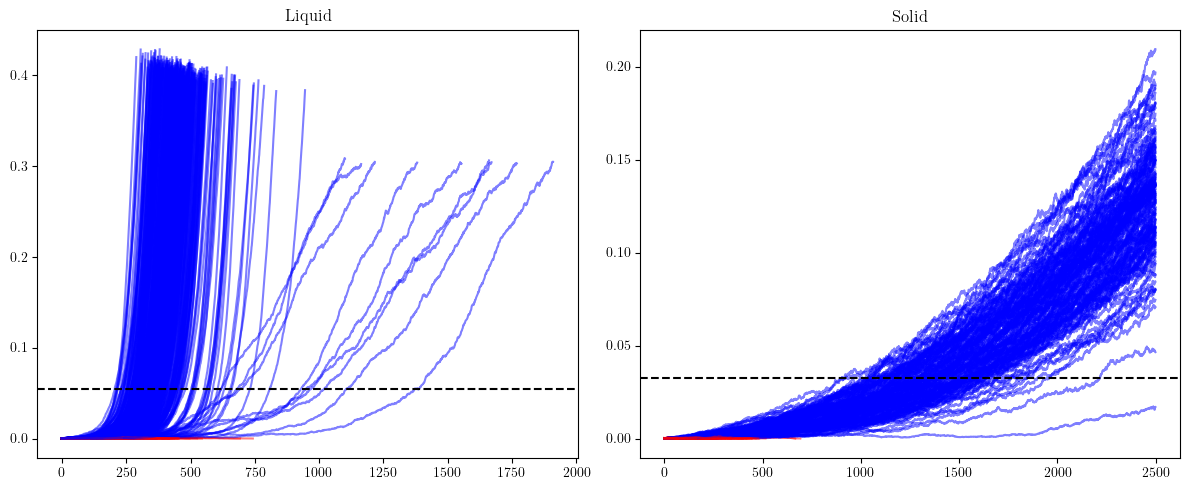

In [30]:
_, ax = plt.subplots(1,2,figsize=(12,5))

for i in range(500):
    if data_l['Diploid'][1][i]['outcome_code']==0:
        ax[0].plot(data_l['Diploid'][1][i]['tumor_density'], color="r", alpha=0.5)
    else:
        ax[0].plot(data_l['Diploid'][1][i]['tumor_density'], color="b", alpha=0.5)

ax[0].axhline(0.054, color="k", ls="--")
ax[0].set_title("Liquid")

for i in range(500):
    if data_s['Diploid'][1][i]['outcome_code']==0:
        ax[1].plot(data_s['Diploid'][1][i]['tumor_density'], color="r", alpha=0.5)
    else:
        ax[1].plot(data_s['Diploid'][1][i]['tumor_density'], color="b", alpha=0.5)

ax[1].axhline(0.032614, color="k", ls="--")
ax[1].set_title("Solid")

plt.tight_layout()

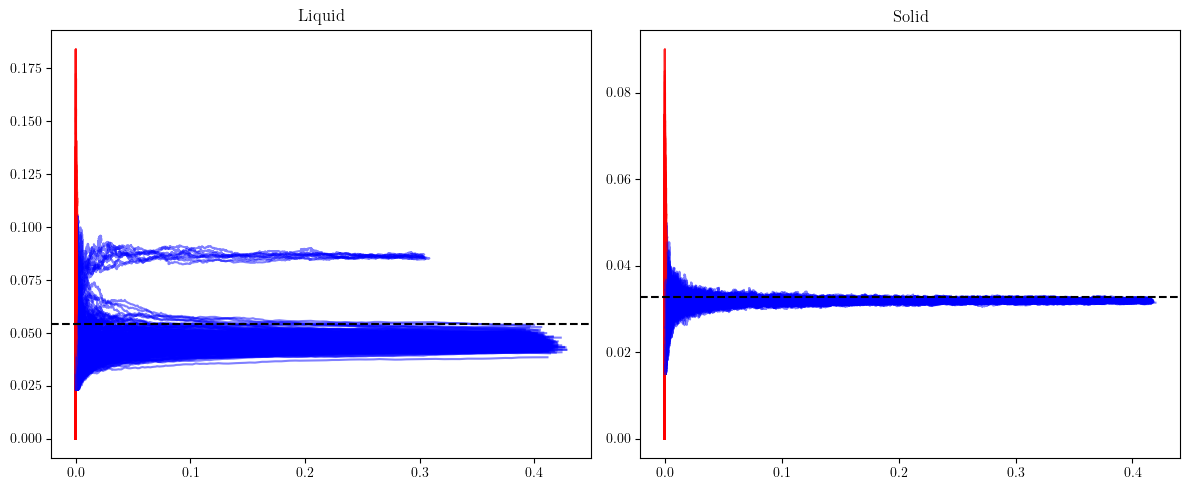

In [8]:
_, ax = plt.subplots(1,2,figsize=(12,5))

for i in range(500):
    if data_l['Diploid'][1][i]['outcome_code']==0:
        ax[0].plot(data_l['Diploid'][1][i]['tumor_density'], data_l['Diploid'][1][i]['mu'], color="r", alpha=0.5)
    else:
        ax[0].plot(data_l['Diploid'][1][i]['tumor_density'], data_l['Diploid'][1][i]['mu'], color="b", alpha=0.5)

ax[0].axhline(0.054, color="k", ls="--")
ax[0].set_title("Liquid")

for i in range(500):
    if data_s['Diploid'][1][i]['outcome_code']==0:
        ax[1].plot(data_s['Diploid'][1][i]['tumor_density'], data_s['Diploid'][1][i]['mu'], color="r", alpha=0.5)
    else:
        ax[1].plot(data_s['Diploid'][1][i]['tumor_density'], data_s['Diploid'][1][i]['mu'], color="b", alpha=0.5)

ax[1].axhline(0.032614, color="k", ls="--")
ax[1].set_title("Solid")

plt.tight_layout()

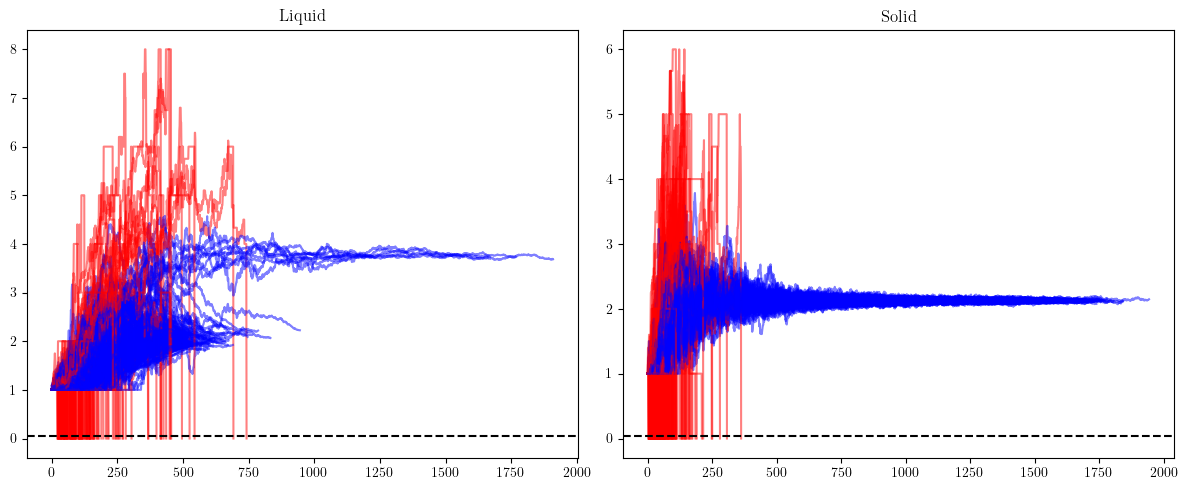

In [9]:
_, ax = plt.subplots(1,2,figsize=(12,5))

for i in range(500):
    if data_l['Diploid'][1][i]['outcome_code']==0:
        ax[0].plot(data_l['Diploid'][1][i]['act_I'], color="r", alpha=0.5)
    else:
        ax[0].plot(data_l['Diploid'][1][i]['act_I'], color="b", alpha=0.5)

ax[0].axhline(0.054, color="k", ls="--")
ax[0].set_title("Liquid")

for i in range(500):
    if data_s['Diploid'][1][i]['outcome_code']==0:
        ax[1].plot(data_s['Diploid'][1][i]['act_I'], color="r", alpha=0.5)
    else:
        ax[1].plot(data_s['Diploid'][1][i]['act_I'], color="b", alpha=0.5)

ax[1].axhline(0.032614, color="k", ls="--")
ax[1].set_title("Solid")

plt.tight_layout()

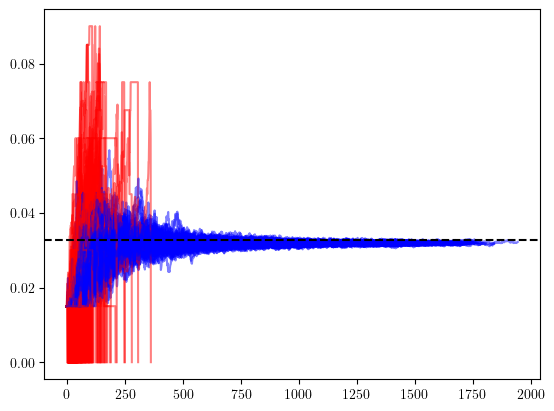

In [10]:
for i in range(500):
    if data_s['Diploid'][1][i]['outcome_code']==0:
        plt.plot(data_s['Diploid'][1][i]['mu'], color="r", alpha=0.5)
    else:
        plt.plot(data_s['Diploid'][1][i]['mu'], color="b", alpha=0.5)

plt.axhline(0.032614, color="k", ls="--")

In [20]:
1-(1/2)**(1/10)

0.06696700846319259

In [ ]:
1-((3/)**(1/10))

-0.04137974399241062

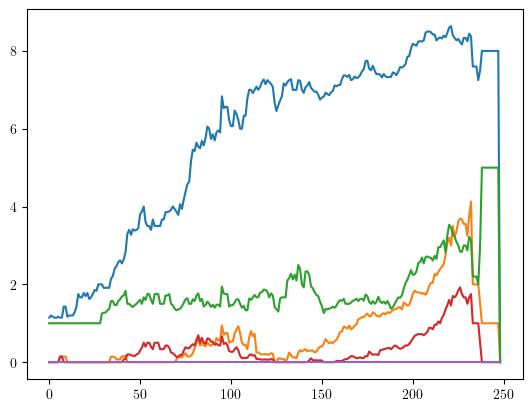

In [9]:
index = 1
plt.plot(data_s['Diploid'][1][index]['act_O'])
plt.plot(data_s['Diploid'][1][index]['act_S'])
plt.plot(data_s['Diploid'][1][index]['act_I'])
plt.plot(data_s['Diploid'][1][index]['act_M'])
plt.plot(data_s['Diploid'][1][index]['act_HK'])

In [91]:
stab = load_stability_results_solid()
stabl = load_stability_results_liquid()

In [35]:
from src.analysis.compute_stability_line import get_critical_survival, get_critical_dmu


In [54]:
rows = []

for rn in x:
    rmax = rn * 0.15
    dmu_star = get_critical_dmu(rmax, 0.15, 1, 10)
    ps_star = get_critical_survival(dmu_star, 10)
    rows.append({
        "rmax_norm": rn,
        "rmax": rmax,
        "dmu_star": dmu_star,
        "P_s_star": ps_star
    })

df = pd.DataFrame(rows)

In [47]:
df

,rmax_norm,rmax,dmu_star,P_s_star
0,1.500000,0.225000,0.018067,0.833333
1,1.555556,0.233333,0.019479,0.821429
2,1.611111,0.241667,0.020810,0.810345
3,1.666667,0.250000,0.022067,0.800000
4,1.722222,0.258333,0.023257,0.790323
...,...,...,...,...
95,6.777778,1.016667,0.054038,0.573770
96,6.833333,1.025000,0.054137,0.573171
97,6.888889,1.033333,0.054234,0.572581
98,6.944444,1.041667,0.054330,0.572000


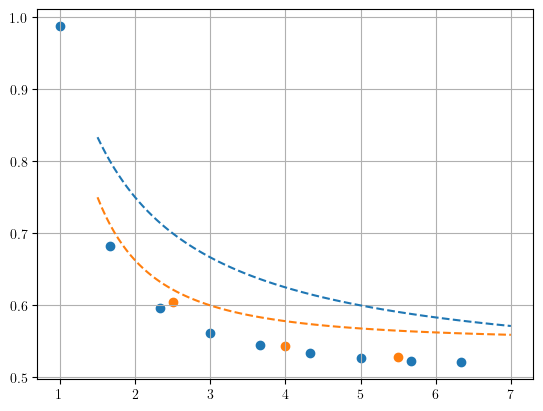

In [92]:
x = np.linspace(1.5,7,100)

def th_t(x):
    vec = []
    for xi in x:
        vec.append(get_critical_survival(xi*0.15, 0.15, 1, 10))
    return np.array(vec)

def th_s(x):
    #return (1-((1+1/x)/2)**0.1)
    return ((1/2)*(1+(1/x)))

def th_l(x, c=0.1):
    #return (1-((1+1/x)/2)**0.1)
    return (1+c+(1-c)*(1/x)**2)/2

def ps(x):
    return (1-x)**(10)

#plt.plot(x, pdeath(th_pred(x)))
plt.scatter(stab['rmax_norm'], ps(stab['stable_dmu']*10), color="C0")
plt.plot(x, th_s(x), color="C0", ls="--")
#plt.plot(x, df['P_s_star'], color="C3")
#plt.axhline(compute_asymptotic_limit(10,10,0.017)['asymp_mu_analytical'], c="C0", ls=":")
plt.scatter(stabl['rmax_norm'], ps(stabl['stable_dmu']*10), color="C1")
plt.plot(x, th_l(x), color="C1", ls="--")
plt.grid()

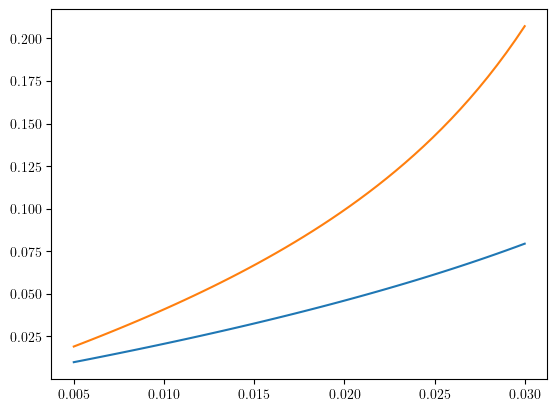

In [56]:
xmu = np.linspace(0.005, 0.03)
plt.plot(xmu, th_b(xmu))
plt.plot(xmu, th_b(xmu,lb=1))

In [12]:
from src.analysis.stationary_liquid import solve_stationary_system

In [13]:
results = solve_stationary_system(
    N_I=10, 
    N_HK=10, 
    dmu=0.018, 
    r0=0.15, 
    rmax=0.30, 
    verbose=True
)

  LIQUID TUMOR — STATIONARY STATE ANALYSIS
  N_I          = 10
  N_HK         = 10
  dmu          = 0.01800
  r0           = 0.1500
  rmax         = 0.3000
  remove-lower = 0
------------------------------------------------------------

  Growth foothold: LHS = 0.030005, RHS = 0.022500
  Margin = 0.007505  =>  INVADABLE
  Critical dmu* = 0.021013

  Converged: True (Regime: Coexistence)
  f_W  = 0.706907
  p_D  = 0.089801
  f_C  = 0.203293 (total cancer)
  <k>  = 1.6037
  <mu> = 0.028866

  Class | f_k*        | alpha_k    | gamma_k    | delta_k
  --------------------------------------------------------
      1 |    0.118859 |   0.708139 |   0.083734 |   0.166098
      2 |    0.055917 |   0.516876 |   0.112084 |   0.306941
      3 |    0.020763 |   0.389179 |   0.114356 |   0.426001
      4 |    0.006071 |   0.302529 |   0.104980 |   0.526326
      5 |    0.001395 |   0.243008 |   0.090849 |   0.610584
      6 |    0.000250 |   0.201887 |   0.075012 |   0.681104
      7 |    0.000035 |

In [14]:
import matplotlib.pyplot as plt

In [15]:
results['f_k']

array([1.18859057e-01, 5.59166807e-02, 2.07625332e-02, 6.07099084e-03,
       1.39461506e-03, 2.50259981e-04, 3.45737755e-05, 3.55174911e-06,
       2.49368275e-07, 9.31690845e-09])

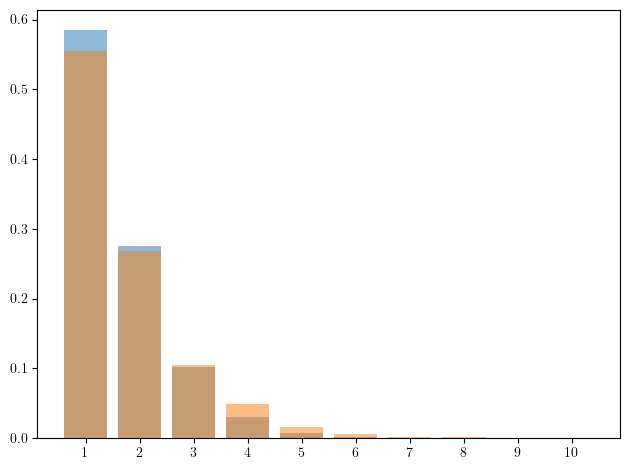

In [16]:
f_d = [0.5550288540807914,
 0.2683429513602638,
 0.10449299258037922,
 0.04843363561417972,
 0.01628194558944765,
 0.0053586150041220115,
 0.001030502885408079,
 0.001030502885408079,
 0.0,
 0.0]

plt.bar(np.arange(1,11),results['f_k']/sum(results['f_k']), alpha=0.5)
plt.bar(np.arange(1,11), f_d, alpha=0.5)
plt.xticks(np.arange(1,11))
plt.tight_layout()